# Initial exploratory data analysis and cleaning

In this notebook, an initial inspection of the raw data is conducted, focusing on the exploration of variables and their distributions, as well as the identification of missing values and duplicate records.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re

In [ ]:
df = pd.read_csv("../data/raw/Reviews.csv")
print(df.shape)
print(df.columns)
print(df.head())

(568454, 10)
Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='str')
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0     

In [4]:
df['Time'] = pd.to_datetime(df['Time'], unit='s')
df['year'] = df['Time'].dt.year

df['review_len'] = df['Text'].astype(str).apply(lambda x: len(x.split()))

In [5]:
df[["Score", "review_len"]].describe()

,Score,review_len
count,568454.000000,568454.000000
mean,4.183199,80.264023
std,1.310436,79.455384
min,1.000000,3.000000
25%,4.000000,33.000000
50%,5.000000,56.000000
75%,5.000000,98.000000
max,5.000000,3432.000000


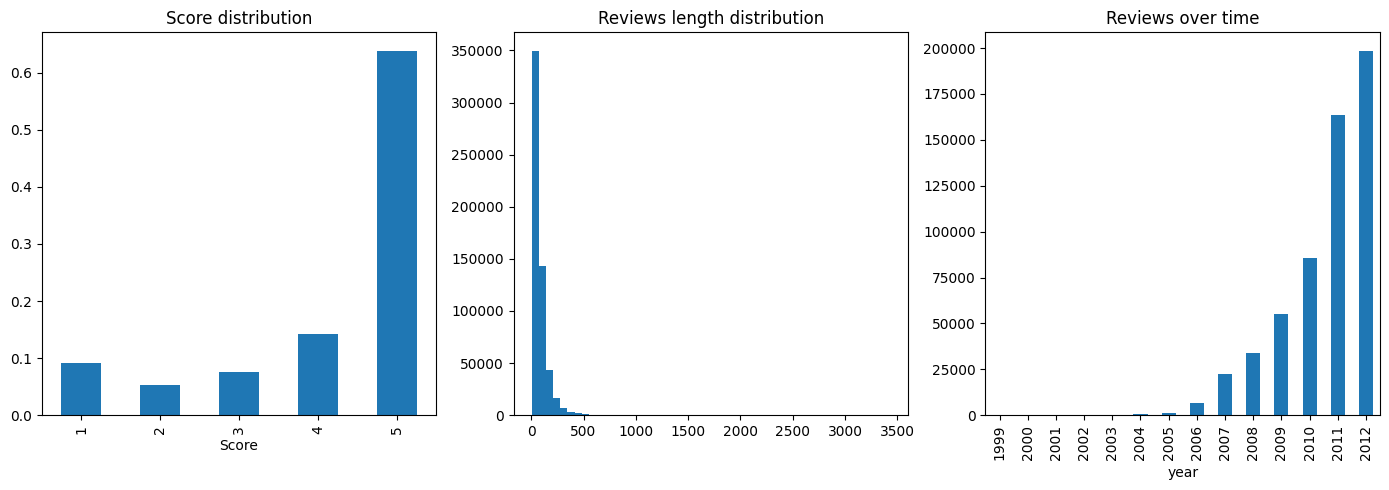

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14,5))

df['Score'].value_counts(normalize=True).sort_index().plot(kind='bar', ax=axes[0], title="Score distribution")
axes[1].hist(df['review_len'], bins=50)
axes[1].set_title("Reviews length distribution")
df['year'].value_counts().sort_index().plot(kind='bar', ax=axes[2], title="Reviews over time")

plt.tight_layout()
plt.show()

### Analysis of missing values and duplicated records

In [7]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicated rows:", df.duplicated().sum())

Missing values:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
year                       0
review_len                 0
dtype: int64

Duplicated rows: 0


While analyzing reviews aggregated by Product and User, a hidden duplication issue was identified. Many reviews in the dataset are identical and associated with multiple ProductIds. After further investigation, the most likely explanation is that Amazon assigns the same review to different flavors or variations of the same product, effectively duplicating the reviews across related items.  
  
Since it is impossible to reliably distinguish every individual product variation, the chosen approach was to remove the duplicates while keeping only one ProductId along with its associated reviews. This decision inevitably results in the loss of information regarding specific flavors or product variations.
  
Further analysis of product variations could be considered separately if deemed important. However, such an analysis would be particularly challenging due to the lack of structured and reliable data describing these variations.

In [8]:
most_reviewed_products = (
    df.groupby('ProductId')
    .agg({
        'Summary': 'first',
        'Text': 'first',
        'UserId': 'count'
    })
    .rename(columns={'UserId': 'n_reviews'})
    .sort_values(by='n_reviews', ascending=False)
)
most_reviewed_products.head(10)

,Summary,Text,n_reviews
ProductId,,,
B007JFMH8M,Delicious!,I love these cookies! Not only are they healt...,913
B002QWP89S,addictive! but works for night coughing in dogs,my 12 year old sheltie has chronic brochotitis...,632
B002QWP8H0,addictive! but works for night coughing in dogs,my 12 year old sheltie has chronic brochotitis...,632
B002QWHJOU,addictive! but works for night coughing in dogs,my 12 year old sheltie has chronic brochotitis...,632
B0026RQTGE,addictive! but works for night coughing in dogs,my 12 year old sheltie has chronic brochotitis...,632
B003B3OOPA,"Taste good, great with honey!","Coconut Oil is so tasty, it goes great with an...",623
B001EO5Q64,"GREAT COCONUT OIL....Try it, you'll like it!",Nutiva is the BEST COCONUT OIL! I love it and ...,567
B0026KPDG8,Yummy snacks!,Popchips are the bomb!! I use the parmesan ga...,564
B000VK8AVK,Yummy snacks!,Popchips are the bomb!! I use the parmesan ga...,564


In [9]:
n_duplicated = df.duplicated(
    subset=['UserId', 'Score', 'Time', 'Summary', 'Text'],
    keep=False
).sum()
print(n_duplicated)

230626


In [10]:
df_clean = df.drop_duplicates(
    subset=['UserId', 'Score', 'Time', 'Summary', 'Text'],
    keep='first'
)
print(df_clean.shape)

(395159, 12)


Another type of unusual duplicated rows was also identified, where the review text and user were exactly the same, while only the review summary or timestamp differed. However, these entries were retained, since they could represent updates or repeated purchases of the same product. Moreover, they accounted for only a small minority of the reviews.

In [11]:
text_dups = df_clean.duplicated(
    subset=['Text'],
    keep=False
)

print("duplicated on text:", text_dups.sum())
df_clean[text_dups].sort_values('Text').head(10)

duplicated on text: 2854


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,year,review_len
257785,257786,B000KOWR8E,A142S4ZZF1FJ1X,Joseph E Brew,2,3,4,2010-10-09,Better Sweetener!,"""4C Totally Light"" is one of the very few ""sug...",2010,33
506745,506746,B000KOWR8Y,A142S4ZZF1FJ1X,Joseph E Brew,0,0,4,2010-10-09,4C Totally Light,"""4C Totally Light"" is one of the very few ""sug...",2010,33
82988,82989,B007TGDXNO,A2QTB6RFY12WGQ,Tuseline Goldstein,1,2,5,2011-12-12,Looooove It!,"""By far the best cup of coffee ever!!!"". I rec...",2011,68
92370,92371,B007TGDXMK,A2QTB6RFY12WGQ,Tuseline Goldstein,2,2,5,2011-12-12,Organic never tasted better!,"""By far the best cup of coffee ever!!!"". I rec...",2011,68
73443,73444,B0046IISFG,A3OXHLG6DIBRW8,"C. F. Hill ""CFH""",1,1,5,2012-07-22,Great Diabetic Friendly Sweetwner - Highly Rec...,"""Erythritol"" has become one of our favorite su...",2012,90
311003,311004,B001EO6FPU,A3OXHLG6DIBRW8,"C. F. Hill ""CFH""",9,9,5,2011-02-07,Great Diabetic Friendly Sweetener - Highly Rec...,"""Erythritol"" has become one of our favorite su...",2011,90
461600,461601,B001EPQMFM,A3OXHLG6DIBRW8,"C. F. Hill ""CFH""",3,3,5,2009-03-07,Great Diabetic Friendly Sweetner! Highly Recom...,"""Splenda"" is one of my favorite things ever! B...",2009,100
542542,542543,B001E50WDA,A3OXHLG6DIBRW8,"C. F. Hill ""CFH""",0,0,5,2009-03-07,Great Diabetic Friendly Sweetener! Highly Reco...,"""Splenda"" is one of my favorite things ever! B...",2009,100
395934,395935,B000PGJI0C,A3OXHLG6DIBRW8,"C. F. Hill ""CFH""",1,1,4,2009-03-07,Really Very Good Diet Hot Cocoa! Recommended!,"""Swiss Miss No Sugar Added Hot Cocoa"" is a ver...",2009,77
540290,540291,B001E4S6TI,A3OXHLG6DIBRW8,"C. F. Hill ""CFH""",2,2,4,2009-03-07,Really Good Diet Hot Cocoa! Recommended!,"""Swiss Miss No Sugar Added Hot Cocoa"" is a ver...",2009,77


Clean reviews from html tags and special characters.

In [12]:
def clean_text(text):
    if pd.isna(text):
        return text
    
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)
    text = text.strip('"').strip("'")
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df_clean['Text'] = df_clean['Text'].apply(clean_text)

Export clean dataset for further tabular and sentiment analysis. Labels were reduced from 5 to 3 classes, in order to reduce balancing issues and reach a reasonable performance. Classes 1 and 2 were merged into a single class (negative), and 4 and 5 were merged into another class (positive).  
Some variables were introduced to facilitate further analysis, such as the length of the review text (numerical and categorical), the helpfulness ratio, and a binary variable indicating whether a review is considered helpful or not.  
The final dataset was exported in two versions: 
-  for BERT fine tuning, containing only the text and label columns
-  for tabular analysis, containing all the introduced variables

In [ ]:
df_clean = df_clean.reset_index(drop=True)

def map_label(score):
    if score <= 2:
        return 0    # negative
    elif score == 3:
        return 1    # neutral
    else:
        return 2    # positive

df_clean['helpfulness_ratio'] = df_clean.apply(
    lambda r: r['HelpfulnessNumerator'] / r['HelpfulnessDenominator']
    if r['HelpfulnessDenominator'] > 0 else float('nan'), axis=1
)
df_clean['is_helpful'] = (df_clean['helpfulness_ratio'] >= 0.7) & (df_clean['HelpfulnessDenominator'] >= 3)
df_clean['length_bin'] = pd.cut(df_clean['review_len'], bins=[0, 50, 100, 300, 1000],
                             labels=['short', 'medium', 'long', 'very_long'])

df_clean["label"] = df_clean["Score"].apply(map_label)

df_clean.to_csv('../data/processed/Reviews_clean.csv', index=False)
df_clean[['Text','label']].rename(columns={'Text':'text'}).to_csv('../data/processed/Reviews_for_tuning.csv', index=False)